# 複数マイクロフォンアレイによるスポットフォーミング

- チェックから始まる項はそれぞれのアルゴリズムチェック
- 最後の「スポットフォーミング」が実際のアルゴリズムの実装

## チェック MUSIC

In [38]:
import pyroomacoustics as pra
import numpy as np
import matplotlib.pyplot as plt

# Room dimensions
room_dim = [10, 10, 3]

# Create a shoebox room
room = pra.ShoeBox(room_dim, fs=16000, max_order=17)

# Source location
source_loc = [3, 4, 1.5]
room.add_source(source_loc)

# Microphone array location and configuration
# Create an 8-channel circular microphone array
center = [5, 5, 1.5]
radius = 0.1
num_microphones = 8
angles = np.linspace(0, 2 * np.pi, num_microphones, endpoint=False)
mic_loc = np.array([
    center[0] + radius * np.cos(angles),
    center[1] + radius * np.sin(angles),
    [center[2]] * num_microphones
])


room.add_microphone_array(mic_loc)

# Simulate the room impulse responses
room.compute_rir()

# Generate some white noise as the source signal
signal = np.random.randn(16000)
room.sources[0].signal = signal

# Simulate the received signals at the microphones
room.simulate()


In [39]:
room.mic_array.signals.shape

(8, 24110)

In [40]:
mic_loc

array([[5.1       , 5.07071068, 5.        , 4.92928932, 4.9       ,
        4.92928932, 5.        , 5.07071068],
       [5.        , 5.07071068, 5.1       , 5.07071068, 5.        ,
        4.92928932, 4.9       , 4.92928932],
       [1.5       , 1.5       , 1.5       , 1.5       , 1.5       ,
        1.5       , 1.5       , 1.5       ]])

In [41]:
## MUSIC実行
from scipy.signal import stft

def doa(mic_signals, mic_loc,  fs, nfft=512, noverlap=512//2,c=343.0,num_src=3):
  # mic_signals: 入力波形 shape: (マイク数, 時間)
  # mic_loc: マイク位置
  # fs: サンプリング周波数
  # nfft: FFT長
  # c: 音速
  # num_src: 推定する音源数

  # 各チャネルでSTFTを実行
  stft_results = []
  for i in range(mic_signals.shape[0]):
      f, t, Zxx = stft(mic_signals[i,:], fs=fs, nperseg=nfft, noverlap=noverlap)
      stft_results.append(Zxx)
  Z=np.array(stft_results) # shape: (マイク数, 周波数ビン数, タイムフレーム数)

  # MUSICオブジェクトを初期化
  music = pra.doa.MUSIC(mic_loc, fs=fs, nfft=nfft, c=c, num_src=num_src)
  # 実行
  music.locate_sources(Z)
  return music

In [42]:
# Get the signals from the microphone array
mic_signals = room.mic_array.signals

music=doa(mic_signals, mic_loc, fs=room.fs)

# Estimate the direction of arrival
music.azimuth_recon

array([5.39306739, 1.6231562 , 3.5081118 ])

Text(0.5, 1.0, 'MUSIC spectra')

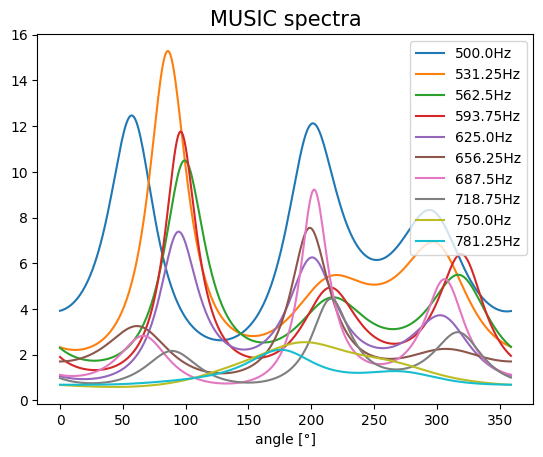

In [43]:
# 低周波数ビンから１０個のみをプロット
index_freq_bins = list(range(music.Pssl.shape[1]))
for k in index_freq_bins[:10]:
    plt.plot(music.Pssl[:,k],label=str(music.freq_hz[k])+"Hz")
plt.xlabel("angle [°]")
plt.legend()
plt.title("MUSIC spectra", fontsize=15)

## チェック Beamforming

In [44]:
import numpy as np
from numpy.fft import rfft, irfft, rfftfreq

# -----------------------------
# 幾何&ステアリングベクトル
# -----------------------------
def circular_array_positions(num_mics: int, radius_m: float) -> np.ndarray:
    """
    円形マイクアレイの各マイク座標を返す（xy平面、z=0）。
    返り値: shape = (num_mics, 3)
    """
    angles = np.linspace(0, 2*np.pi, num_mics, endpoint=False)
    x = radius_m * np.cos(angles)
    y = radius_m * np.sin(angles)
    z = np.zeros_like(x)
    return np.stack([x, y, z], axis=1)

def unit_vec_from_angles(azimuth_deg: float, elevation_deg: float) -> np.ndarray:
    """
    方位角(0°=x軸正方向, 反時計回り)・仰角(0°=xy平面, +で上向き)から単位ベクトルuを生成。
    """
    az = np.deg2rad(azimuth_deg)
    el = np.deg2rad(elevation_deg)
    u = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ], dtype=float)
    return u / np.linalg.norm(u)

def steering_vector(freqs: np.ndarray,
                    mic_positions: np.ndarray,
                    doa_unitvec: np.ndarray,
                    c: float = 343.0) -> np.ndarray:
    """
    ステアリングベクトル a(f, u) を返す。
    a_m(f) = exp( -j 2π f τ_m ), τ_m = (r_m · u)/c
    返り値: shape = (K, M)  (K=len(freqs), M=num_mics)
    """
    # 各マイクの幾何遅延（到来時間差）
    taus = -(mic_positions @ doa_unitvec) / c  # shape: (M,)
    # f×tau の外積 → 位相項
    phase = -2j * np.pi * freqs[:, None] * taus[None, :]  # (K, M)
    return np.exp(phase)

# -----------------------------
# DS（Delay-and-Sum）ビームフォーミング
# -----------------------------
def ds_beamform_time(y_multi: np.ndarray,
                     fs: int,
                     mic_positions: np.ndarray,
                     azimuth_deg: float,
                     elevation_deg: float = 0.0,
                     c: float = 343.0,
                     normalize: bool = True) -> np.ndarray:
    """
    周波数領域で位相シフトして和を取る DS ビームフォーマ。
    y_multi: shape=(N, M) の観測（Mチャネル）
    返り値: shape=(N,) のビーム出力
    """
    assert y_multi.ndim == 2, "y_multi must be (N, M)"
    N, M = y_multi.shape

    # FFT（実数rFFT） (K=len(freqs), M=num_mics)
    Y = rfft(y_multi, axis=0)                # (K, M)
    freqs = rfftfreq(N, d=1.0/fs)            # (K,)

    # 目標DOAのステアリングベクトル
    u = unit_vec_from_angles(azimuth_deg, elevation_deg)
    A = steering_vector(freqs, mic_positions, u, c=c)     # (K, M)

    # DSは conj(a) を重みとして合成（= 到来方向に位相合わせ）
    # W = conj(A), 出力は各周波数で内積
    #print(A)
    #print(np.conj(A))

    #Y_beam = np.sum(np.conj(A) * Y, axis=1)  # (K,)
    Y_beam = np.sum(A * Y, axis=1)  # (K,)


    if normalize:
        Y_beam /= M  # 振幅の正規化（任意）

    y_beam = irfft(Y_beam, n=N)
    return y_beam



In [45]:
fs = 16000
dur = 1.0
N = int(fs * dur)
t = np.arange(N) / fs

# アレイ定義
M = 8
#R = 0.04  # 半径:4 cm
R = 0.06  # 半径:6 cm (見易さのため)
mic_pos = circular_array_positions(M, R)

# 入射波（平面波）パラメータ
true_az = 45.0      # 実際の到来方位
true_el = 0.0
c = 343.0

# テスト音（1kHzサイン + ノイズ）
f0 = 440.0
s = 0.8 * np.sin(2*np.pi*f0*t)

# 各マイクへの到来遅延を付与して多チャネル合成
u_true = unit_vec_from_angles(true_az, true_el)

taus = -(mic_pos @ u_true) / c  # shape: (M,)
# 周波数領域での高精度遅延付与（位相シフト）
X = np.fft.rfft(s)  # (K,)
freqs = np.fft.rfftfreq(N, d=1/fs)
Y_multi = np.zeros((len(s), M), dtype=float)

for m in range(M):
    phase = np.exp(- 2j * np.pi * freqs * taus[m])  # x(t - tau) を作るなら exp(-j2πf tau)
    # 平面波がマイク m に tau[m] だけ「遅延」して到達する状況をシミュレートするために
    # s(t - tau[m])（=スペクトルに exp(-j2πf tau[m])）を用いる
    y_m = np.fft.irfft(X * phase, n=N).real
    # ノイズを加える
    y_m += 0.01 * np.random.randn(N)
    Y_multi[:, m] = y_m

#### ここまで Y_multi 生成

# DS ビーム（正しい方向へ）
y_ds = ds_beamform_time(Y_multi, fs, mic_pos, azimuth_deg=true_az, elevation_deg=true_el, c=c)

# 誤った方向に向けた場合（例：-60°）
y_ds_wrong = ds_beamform_time(Y_multi, fs, mic_pos, azimuth_deg=-30.0, elevation_deg=0.0, c=c)


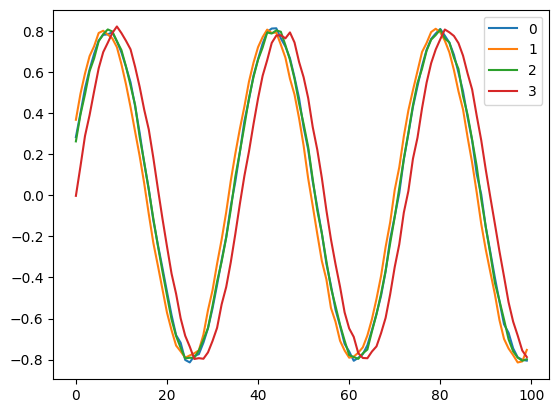

In [46]:
# 元は波形チェック（見易さのために半分のチャネルのみ表示）
for i in range(4):
  plt.plot(Y_multi[:100,i],label=str(i))
plt.legend()

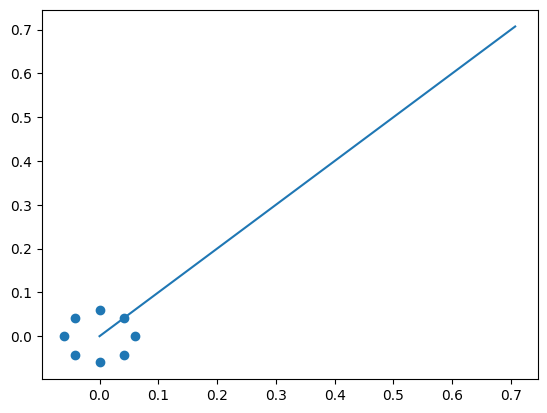

In [47]:
#
plt.scatter(mic_pos[:,0],mic_pos[:,1])
plt.plot([0,u_true[0]],[0,u_true[1]])


Text(0.5, 0, 'mic')

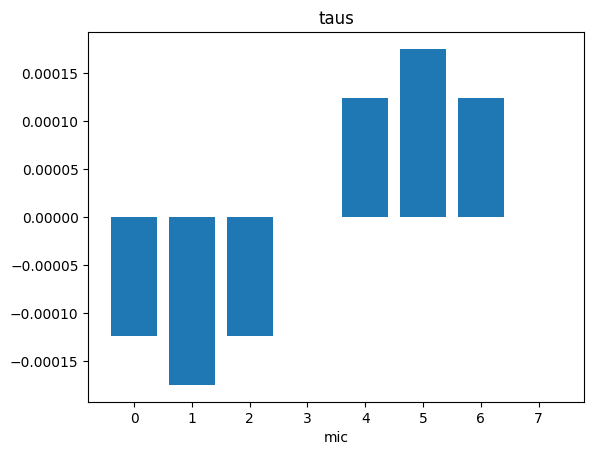

In [48]:
plt.title('taus')
plt.bar(range(len(taus)),taus)
plt.xlabel('mic')


Text(0, 0.5, 'power')

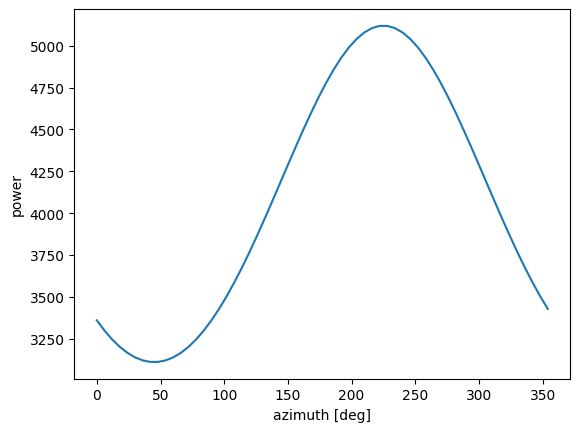

In [49]:
b=[]
for i in range(60):
  y_temp = ds_beamform_time(Y_multi, fs, mic_pos, azimuth_deg=i*6, elevation_deg=0, c=c)
  b.append(np.sum(y_temp**2))
plt.plot([i*6 for i in range(60)],b)
plt.xlabel('azimuth [deg]')
plt.ylabel('power')

In [50]:
def tone_fit_snr(x, fs, f0):
    """
    Fit a*cos(2πf0 t) + b*sin(2πf0 t) to x (least squares) and compute SNR (dB):
    SNR = P(fitted tone) / P(residual)
    """
    N = len(x)
    t = np.arange(N)/fs
    A = np.column_stack([np.cos(2*np.pi*f0*t), np.sin(2*np.pi*f0*t)])
    coef, *_ = np.linalg.lstsq(A, x, rcond=None)
    x_hat = A @ coef
    Ps = np.mean(x_hat**2) + 1e-20
    Pn = np.mean((x - x_hat)**2) + 1e-20
    return 10*np.log10(Ps/Pn)


SNR (tone-fit):
  Single mic: 35.12 dB
  DS (steer target): 41.83 dB
  DS (steer wrong): 42.71 dB


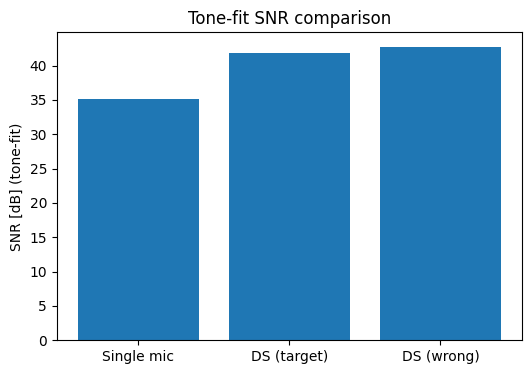

In [51]:
# １chだけvs正解方向vs間違った方向のビームフォーミングSNR比較
# Compute SNRs via tone-fit
ref = Y_multi[:, 0]
snr_ref = tone_fit_snr(ref, fs, f0)
snr_ds = tone_fit_snr(y_ds, fs, f0)
snr_wrong = tone_fit_snr(y_ds_wrong, fs, f0)

# Print numerics
print(f"SNR (tone-fit):\n  Single mic: {snr_ref:.2f} dB\n  DS (steer target): {snr_ds:.2f} dB\n  DS (steer wrong): {snr_wrong:.2f} dB")

# Plot bar chart (single plot, no custom colors/styles)
labels = ["Single mic", "DS (target)", "DS (wrong)"]
values = [snr_ref, snr_ds, snr_wrong]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("SNR [dB] (tone-fit)")
plt.title("Tone-fit SNR comparison")
plt.show()

## チェック NMF

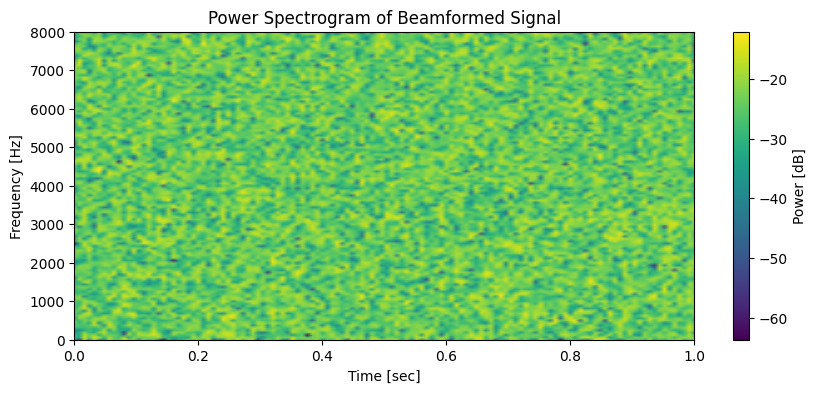

In [52]:
sig=np.random.randn(16000)

from scipy.signal import stft
import matplotlib.pyplot as plt
import numpy as np

# パワースペクトログラムの計算
f_stft, t_stft, Zxx = stft(sig, fs=room.fs)

# パワースペクトログラム (振幅の2乗)
power_spectrogram = np.abs(Zxx) ** 2

# パワースペクトログラムの表示
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft, 10 * np.log10(power_spectrogram), shading='gouraud')
plt.title('Power Spectrogram of Beamformed Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.ylim([0, room.fs / 2])  # サンプリング周波数の半分までを表示
plt.show()

基底 (W) の形状: (129, 3)
アクティベーション (H) の形状: (3, 126)


/home/hiratsuka/SourceCode/SoundIL/.venv/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


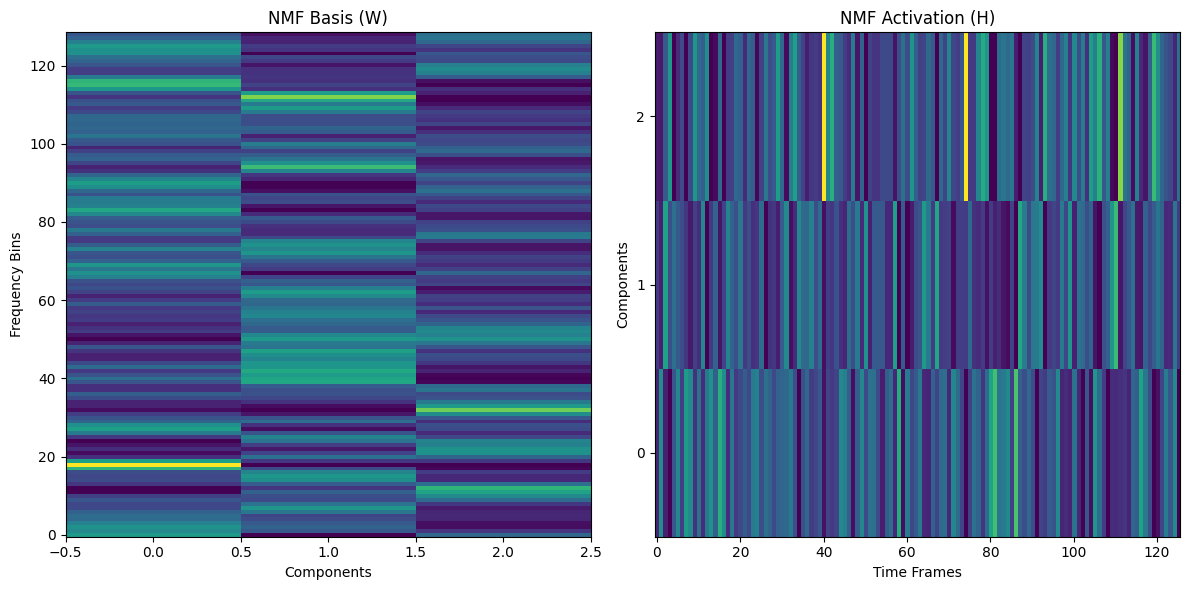

In [53]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

# NMFモデルの作成
# n_componentsは分解後の基底数を指定します。ここでは仮に3とします。
n_components = 3
model = NMF(n_components=n_components, init='random', random_state=0)

# パワースペクトログラムをNMFに適用
# NMFは非負の入力データを想定しているため、power_spectrogramを使用します。
# fit_transformメソッドで分解と同時に変換を行います。
W = model.fit_transform(power_spectrogram) # 基底 (Basis)
H = model.components_ # アクティベーション (Activation)

print("基底 (W) の形状:", W.shape)
print("アクティベーション (H) の形状:", H.shape)

# 基底とアクティベーションの可視化 (オプション)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(W, aspect='auto', origin='lower', cmap='viridis')
plt.title('NMF Basis (W)')
plt.xlabel('Components')
plt.ylabel('Frequency Bins')

plt.subplot(1, 2, 2) # 3xフレーム数　の行列
plt.imshow(H, aspect='auto', origin='lower', cmap='viridis')
plt.yticks(list(range(n_components)))
plt.title('NMF Activation (H)')
plt.xlabel('Time Frames')
plt.ylabel('Components')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Components')

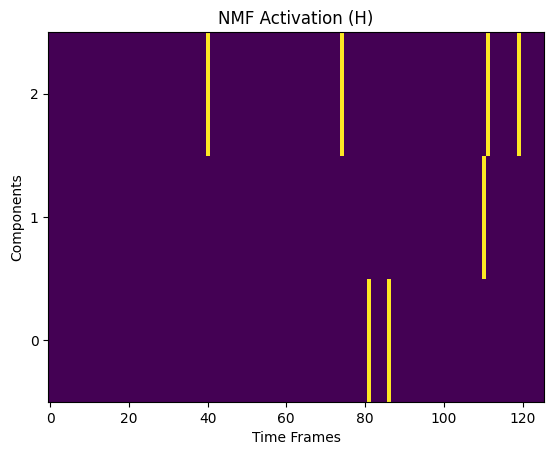

In [54]:
threshold=0.1
plt.imshow(H>0.1, aspect='auto', origin='lower', cmap='viridis', interpolation=None)
plt.yticks(list(range(n_components)))
plt.title('NMF Activation (H)')
plt.xlabel('Time Frames')
plt.ylabel('Components')


## スポットフォーミング

In [55]:
# MUSIC/DS beamforming定義

from scipy.signal import stft

def doa(mic_signals, mic_loc,  fs, nfft=512, noverlap=512//2,c=343.0,num_src=3):
  # mic_signals: 入力波形 shape: (マイク数, 時間)
  # mic_loc: マイク位置
  # fs: サンプリング周波数
  # nfft: FFT長
  # c: 音速
  # num_src: 推定する音源数

  # 各チャネルでSTFTを実行
  stft_results = []
  for i in range(mic_signals.shape[0]):
      f, t, Zxx = stft(mic_signals[i,:], fs=fs, nperseg=nfft, noverlap=noverlap)
      stft_results.append(Zxx)
  Z=np.array(stft_results) # shape: (マイク数, 周波数ビン数, タイムフレーム数)

  # MUSICオブジェクトを初期化
  music = pra.doa.MUSIC(mic_loc, fs=fs, nfft=nfft, c=c, num_src=num_src)
  # 実行
  music.locate_sources(Z)
  return music

import numpy as np
from numpy.fft import rfft, irfft, rfftfreq

# -----------------------------
# 幾何&ステアリングベクトル
# -----------------------------
def circular_array_positions(num_mics: int, radius_m: float) -> np.ndarray:
    """
    円形マイクアレイの各マイク座標を返す（xy平面、z=0）。
    返り値: shape = (num_mics, 3)
    """
    angles = np.linspace(0, 2*np.pi, num_mics, endpoint=False)
    x = radius_m * np.cos(angles)
    y = radius_m * np.sin(angles)
    z = np.zeros_like(x)
    return np.stack([x, y, z], axis=1)

def unit_vec_from_angles(azimuth_deg: float, elevation_deg: float) -> np.ndarray:
    """
    方位角(0°=x軸正方向, 反時計回り)・仰角(0°=xy平面, +で上向き)から単位ベクトルuを生成。
    """
    az = np.deg2rad(azimuth_deg)
    el = np.deg2rad(elevation_deg)
    u = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ], dtype=float)
    return u / np.linalg.norm(u)

def steering_vector(freqs: np.ndarray,
                    mic_positions: np.ndarray,
                    doa_unitvec: np.ndarray,
                    c: float = 343.0) -> np.ndarray:
    """
    ステアリングベクトル a(f, u) を返す。
    a_m(f) = exp( -j 2π f τ_m ), τ_m = (r_m · u)/c
    返り値: shape = (K, M)  (K=len(freqs), M=num_mics)
    """
    # 各マイクの幾何遅延（到来時間差）
    taus = -(mic_positions @ doa_unitvec) / c  # shape: (M,)
    # f×tau の外積 → 位相項
    phase = -2j * np.pi * freqs[:, None] * taus[None, :]  # (K, M)
    return np.exp(phase)

# -----------------------------
# DS（Delay-and-Sum）ビームフォーミング
# -----------------------------
def ds_beamform_time(y_multi: np.ndarray,
                     fs: int,
                     mic_positions: np.ndarray,
                     azimuth_deg: float,
                     elevation_deg: float = 0.0,
                     c: float = 343.0,
                     normalize: bool = True) -> np.ndarray:
    """
    周波数領域で位相シフトして和を取る DS ビームフォーマ。
    y_multi: shape=(N, M) の観測（Mチャネル）
    返り値: shape=(N,) のビーム出力
    """
    assert y_multi.ndim == 2, "y_multi must be (N, M)"
    N, M = y_multi.shape

    # FFT（実数rFFT） (K=len(freqs), M=num_mics)
    Y = rfft(y_multi, axis=0)                # (K, M)
    freqs = rfftfreq(N, d=1.0/fs)            # (K,)

    # 目標DOAのステアリングベクトル
    u = unit_vec_from_angles(azimuth_deg, elevation_deg)
    A = steering_vector(freqs, mic_positions, u, c=c)     # (K, M)

    # DSは conj(a) を重みとして合成（= 到来方向に位相合わせ）
    # W = conj(A), 出力は各周波数で内積
    #print(A)
    #print(np.conj(A))

    #Y_beam = np.sum(np.conj(A) * Y, axis=1)  # (K,)
    Y_beam = np.sum(A * Y, axis=1)  # (K,)


    if normalize:
        Y_beam /= M  # 振幅の正規化（任意）

    y_beam = irfft(Y_beam, n=N)
    return y_beam



In [56]:
import pyroomacoustics as pra
import numpy as np
import matplotlib.pyplot as plt

def get_micarray_pos(x,y):
  radius = 0.03
  num_microphones = 8
  angles = np.linspace(0, 2 * np.pi, num_microphones, endpoint=False)
  center=[x,y,0.3]
  mic_loc = np.array([
      center[0] + radius * np.cos(angles),
      center[1] + radius * np.sin(angles),
      [center[2]] * num_microphones
  ])
  return mic_loc

# Room dimensions
room_dim = [10, 10, 3]
# Create a shoebox room
room = pra.ShoeBox(room_dim, fs=16000, max_order=17)
# Source location
source_loc = [5, 5, 1.5]
room.add_source(source_loc)

# Microphone array location and configuration
# Create an 8-channel circular microphone array
mic_loc1=get_micarray_pos(5+2*np.cos(-30/180*np.pi),5+2*np.sin(-30/180*np.pi))
mic_loc2=get_micarray_pos(5+2*np.cos(91/180*np.pi),5+2*np.sin(90/180*np.pi))
mic_loc3=get_micarray_pos(5+2*np.cos(210/180*np.pi),5+2*np.sin(210/180*np.pi))
room.add_microphone_array(mic_loc1)
room.add_microphone_array(mic_loc2)
room.add_microphone_array(mic_loc3)

# Simulate the room impulse responses
room.compute_rir()

# Generate some white noise as the source signal
signal = np.random.randn(16000)
room.sources[0].signal = signal

# Simulate the received signals at the microphones
room.simulate()


In [57]:
# 8 * 3 ch
room.mic_array.signals.shape

(24, 24106)

In [ ]:
signals1=room.mic_array.signals[:8]
signals2=room.mic_array.signals[8:16]
signals3=room.mic_array.signals[16:]

signal_list=[signals1,signals2,signals3]

In [59]:
music1=doa(signals1, mic_loc1, fs=room.fs, num_src=3)
music2=doa(signals2, mic_loc2, fs=room.fs, num_src=3)
music3=doa(signals3, mic_loc3, fs=room.fs, num_src=3)
print("DoA: mic_array 1:", music1.azimuth_recon*180/np.pi)
print("DoA: mic_array 2:", music2.azimuth_recon*180/np.pi)
print("DoA: mic_array 3:", music3.azimuth_recon*180/np.pi)


DoA: mic_array 1: [289.   8. 145.]
DoA: mic_array 2: [ 91. 268.]
DoA: mic_array 3: [251. 172.  35.]


Text(0.5, 1.0, 'simulation setting')

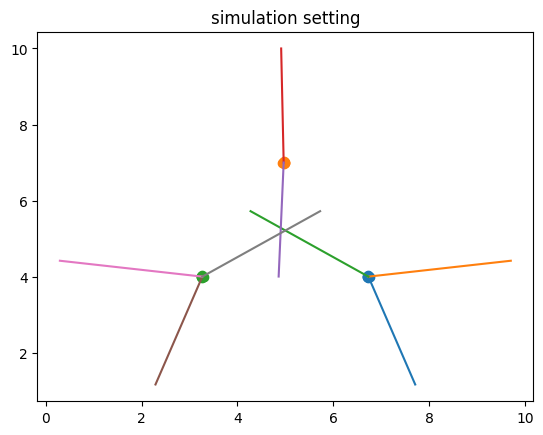

In [60]:
plt.scatter([mic_loc1[0]],[mic_loc1[1]])
plt.scatter([mic_loc2[0]],[mic_loc2[1]])
plt.scatter([mic_loc3[0]],[mic_loc3[1]])

for music, loc in zip([music1,music2,music3],[mic_loc1,mic_loc2,mic_loc3]):
    theta=music.azimuth_recon
    x1=np.mean(loc[0])
    y1=np.mean(loc[1])
    x2_list=np.mean(loc[0])+np.cos(theta)*3.0
    y2_list=np.mean(loc[1])+np.sin(theta)*3.0
    for x2,y2 in zip(x2_list,y2_list):
      plt.plot([x1,x2],[y1,y2])
plt.title("simulation setting")

Text(0.5, 0, 'direction')

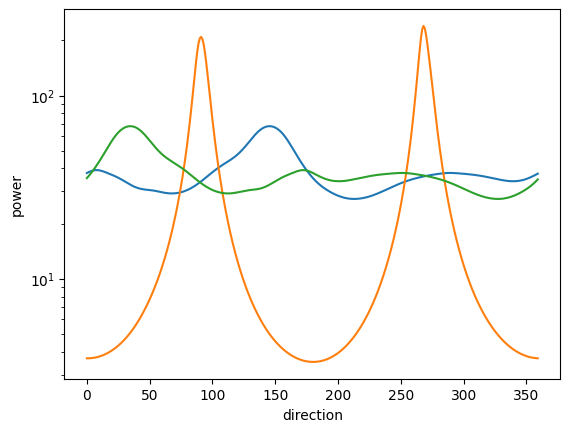

In [61]:
plt.plot(np.mean(music1.Pssl,axis=1))
plt.plot(np.mean(music2.Pssl,axis=1))
plt.plot(np.mean(music3.Pssl,axis=1))
plt.yscale("log")
plt.ylabel("power")
plt.xlabel("direction")



In [25]:
def make_2dmap(N,map_scale,music_list,mic_loc_list):
  X=np.zeros((N,N))
  for i in range(N):
    for j in range(N):
      for music, loc in zip(music_list,mic_loc_list):
        spec=np.log10(np.mean(music.Pssl,axis=1))
        spec=spec/np.sum(spec)
        cx=np.mean(loc[0])
        cy=np.mean(loc[1])
        x=i/map_scale
        y=j/map_scale
        theta=np.atan2((y-cy),(x-cx))
        d=np.sqrt((y-cy)**2+(x-cx)**2)
        X[i,j]+=spec[int(theta/(2*np.pi/len(spec)))]/(d+10)
  return X

map_scale=10
music_list=[music1,music2,music3]
mic_loc_list=[mic_loc1,mic_loc2,mic_loc3]


X=make_2dmap(N=100,map_scale=map_scale,music_list=music_list,mic_loc_list=mic_loc_list)


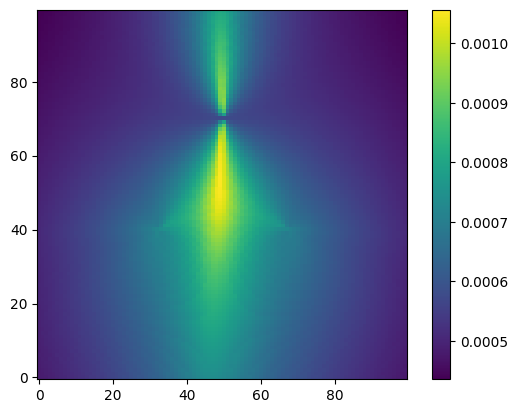

In [26]:
plt.imshow(X.T,origin="lower") # 座標を通常のx-yに合わせてプロット
plt.colorbar()

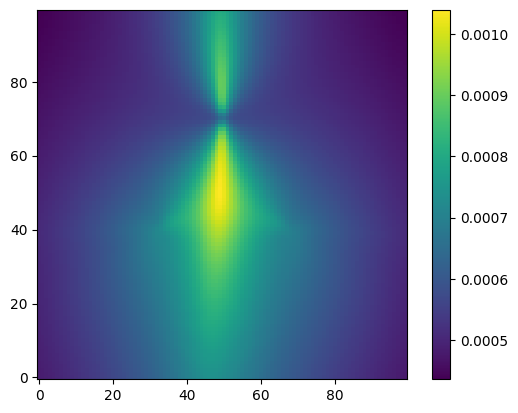

In [27]:
from scipy.ndimage import gaussian_filter
# ガウシアンフィルタでぼやかす
X2 = gaussian_filter(X, 1)
plt.imshow(X2.T,origin="lower")
plt.colorbar()

上位 3 個のピーク点 (NumPy, row, col):
(np.float64(4.9), np.float64(5.0))
(np.float64(4.9), np.float64(8.0))


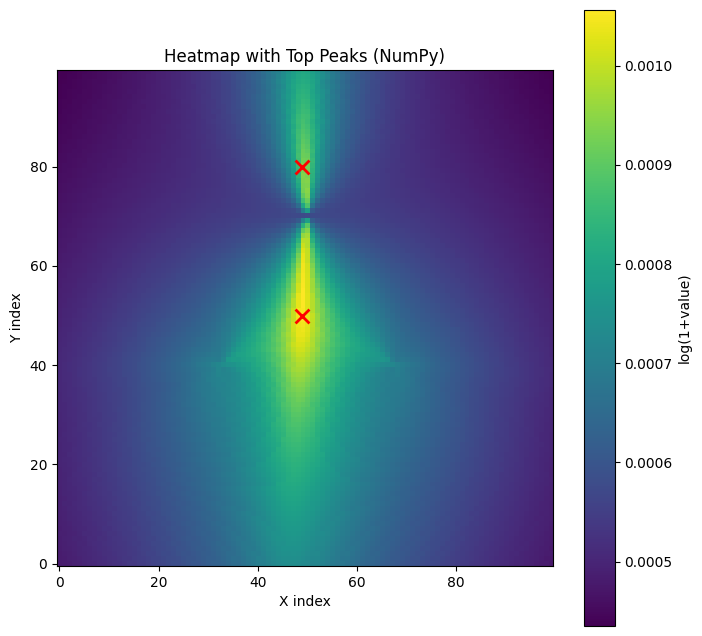

In [28]:
from scipy.signal import find_peaks
import numpy as np
from scipy.ndimage import gaussian_filter


def find_top_k_peaks_numpy(data, k, map_scale, distance=10):
    """
    2次元データからピーク点を抽出し、ピーク点らしさ順にk個選択する（NumPyを使用）

    Args:
        data (np.ndarray): 2次元データ (N, M)
        k (int): 選択するピーク点の数
        map_scale: 座標とインデックスのスケールの違い
        distance (int): ピーク点として検出する際の最小距離

    Returns:
        list: ピーク点の座標 (row, col) のリスト。ピーク点らしさ順にソートされる。
    """
    # ローカル最大値を検出（近傍8点と比較）
    # dataを上下左右、斜めにシフトさせたものと比較
    rows, cols = data.shape
    is_peak = np.ones_like(data, dtype=bool)

    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue
            # シフトした配列を作成
            shifted_data = np.roll(data, shift=(dr, dc), axis=(0, 1))
            # 元のデータがシフトしたデータ以上であるか（境界を除く）
            # ロールバックして比較
            comparison = data >= shifted_data
            # 境界処理: ロールした際に反対側から来た部分を False にする
            if dr != 0:
                if dr == 1: comparison[:dr, :] = True # 上端から来た部分
                else: comparison[dr:, :] = True # 下端から来た部分
            if dc != 0:
                if dc == 1: comparison[:, :dc] = True # 左端から来た部分
                else: comparison[:, dc:] = True # 右端から来た部分

            is_peak &= comparison

    # ピーク点のインデックスを取得
    peak_rows, peak_cols = np.where(is_peak)

    # ピーク点らしさを評価（ここでは単純にピーク値を使用）
    # または、近傍との差の合計なども考えられるが、今回は簡潔さのためピーク値
    peak_values = data[peak_rows, peak_cols]

    # ピーク値の高い順にソートし、上位k個を選択
    sorted_indices = np.argsort(peak_values)[::-1]
    top_k_indices = sorted_indices[:k]

    top_k_peaks = [(peak_rows[i]/map_scale, peak_cols[i]/map_scale) for i in top_k_indices]

    # distance パラメータを考慮して、近すぎるピークをフィルタリングすることも可能ですが、
    # この実装では単純なローカル最大値検出に基づいています。
    # より厳密な距離ベースのフィルタリングが必要な場合は、別途実装が必要です。
    # 例: ピーク間の距離を計算し、近いものを排除

    return top_k_peaks

# X からピーク点を抽出し、上位k個を選択
k = 3

# ガウシアンフィルタで細かいピークを除去
X2 = gaussian_filter(X, 1)
top_peaks = find_top_k_peaks_numpy(X2, k, map_scale=map_scale)

print(f"上位 {k} 個のピーク点 (NumPy, row, col):")
for peak in top_peaks:
    print(peak)

# ピーク点を元の画像に重ねて表示
plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(X).T, cmap='viridis',origin="lower")
plt.colorbar(label='log(1+value)')
plt.title('Heatmap with Top Peaks (NumPy)')
plt.xlabel('X index')
plt.ylabel('Y index')

# ピーク点にマーカーを追加
for peak in top_peaks:
    plt.scatter(peak[0]*map_scale, peak[1]*map_scale, color='red', marker='x', s=100, linewidths=2)
plt.show()

In [29]:
top_peaks


[(np.float64(4.9), np.float64(5.0)), (np.float64(4.9), np.float64(8.0))]

In [30]:
def get_peek_direction_from_mic(top_peaks, mic_loc):
  #top_peaksのマイク位置からの角度
  dx=np.array(top_peaks)-np.mean(mic_loc,axis=1)[:2]
  return np.atan2(dx[:,1],dx[:,0])


In [31]:
# マイクの数 x 推定音源位置（ピークの数）のBeamformingによる強調音声の取得

beamform_wav=[]
for mic_loc,signal in zip(mic_loc_list,signal_list):
  pos=mic_loc.T
  cm=np.mean(pos,axis=0)
  pos=pos-cm
  theta_list=get_peek_direction_from_mic(top_peaks, mic_loc)
  wav=[]
  for theta in theta_list:
    print("DS: mic=",cm,"theta=",theta)
    wav.append(ds_beamform_time(signal.T, fs=room.fs, mic_positions=pos,azimuth_deg=theta))
  beamform_wav.append(wav)


DS: mic= [6.73205081 4.         0.3       ] theta= 2.6419516909369536
DS: mic= [6.73205081 4.         0.3       ] theta= 2.0002936042599178
DS: mic= [4.96509519 7.         0.3       ] theta= -1.6033324346044735
DS: mic= [4.96509519 7.         0.3       ] theta= 1.6357998025558855
DS: mic= [3.26794919 4.         0.3       ] theta= 0.5497243583741316
DS: mic= [3.26794919 4.         0.3       ] theta= 1.1834015898468766


In [32]:
len(beamform_wav[0])

2

In [33]:

def select_binary_mask(beamform_wav, index_estimated_src, fs, threshold=0.01, n_components = 3):
  n_estimated_src=len(beamform_wav[0])
  all_mic_results=[]
  for wavs in beamform_wav:
    wav=wavs[index_estimated_src]
    # パワースペクトログラムの計算
    f_stft, t_stft, Zxx = stft(wav, fs=fs)

    # パワースペクトログラム (振幅の2乗)
    power_spectrogram = np.abs(Zxx) ** 2

    model = NMF(n_components=n_components, init='random', random_state=0)

    # パワースペクトログラムをNMFに適用
    # NMFは非負の入力データを想定しているため、power_spectrogramを使用します。
    # fit_transformメソッドで分解と同時に変換を行います。
    W = model.fit_transform(power_spectrogram) # 基底 (Basis)
    H = model.components_ # アクティベーション (Activation)
    all_mic_results.append((wav,power_spectrogram, W, H))
  _,_,_,H = all_mic_results[0]
  M=H
  for _,_,_,H in all_mic_results[1:]:
    M=np.minimum(M,H)
  Mask=M>threshold
  return f_stft, t_stft, Mask, all_mic_results

# 最終的に各スポットごとに平均化してスペクトログラムを再構成
def recons_spec(beamform_wav, n_components, fs=None, plot_mask=False,plot_spec=False):
  n_estimated_src=len(beamform_wav[0])
  for i in range(n_estimated_src):
    f_stft, t_stft, Mask, results = select_binary_mask(beamform_wav,n_components=n_components,fs=fs, index_estimated_src=i, threshold=0.01)
    if plot_mask:
      # マスクの表示
      plt.imshow(Mask, aspect='auto', origin='lower', cmap='viridis', interpolation=None)
      plt.yticks(list(range(n_components)))
      plt.title('Mask from Hs')
      plt.xlabel('Time Frames')
      plt.ylabel('Components')
      plt.show()
    recons = [W @ (Mask * H) for wav, power_spectrogram, W, H in results]
    recons_all = np.mean(recons, axis=0)
    if plot_spec:
      # 再構成パワースペクトログラムの表示
      plt.figure(figsize=(10, 4))
      plt.pcolormesh(t_stft, f_stft, 10 * np.log10(recons_all + 1e-10), shading='gouraud')
      plt.title('Power Spectrogram of Beamformed Signal')
      plt.ylabel('Frequency [Hz]')
      plt.xlabel('Time [sec]')
      plt.colorbar(label='Power [dB]')
      plt.ylim([0, fs / 2])  # サンプリング周波数の半分までを表示
      plt.show()
  return recons, f_stft, t_stft

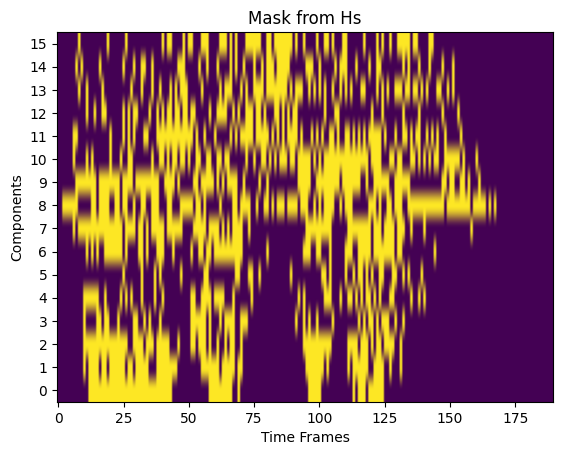

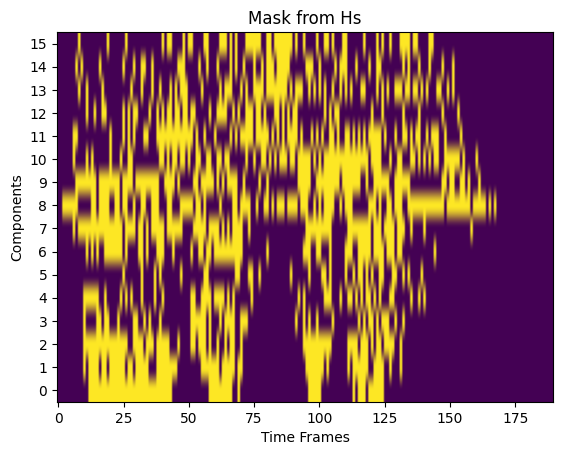

In [34]:
# beamform_wavからスポットのスペクトログラムを再構成する
X_recons,f_stft, t_stft = recons_spec(beamform_wav, n_components=16, fs=room.fs, plot_mask=True, plot_spec=False)

In [35]:
X_recons = np.array(X_recons)
recons_spec = np.mean(X_recons, axis=0) # 129, 190

beamform_wav = np.array(beamform_wav)
beamform_spec=[]
for wavs in beamform_wav:
    for wav in wavs:
        f_stft, t_stft, Zxx = stft(wav, fs=room.fs)
        power_spectrogram = np.abs(Zxx) ** 2
        beamform_spec.append(power_spectrogram)
beamform_spec = np.array(beamform_spec)
mean_spec = np.mean(beamform_spec, axis=0) # 129, 190
print(recons_spec.shape)
print(mean_spec.shape)

(129, 190)
(129, 190)


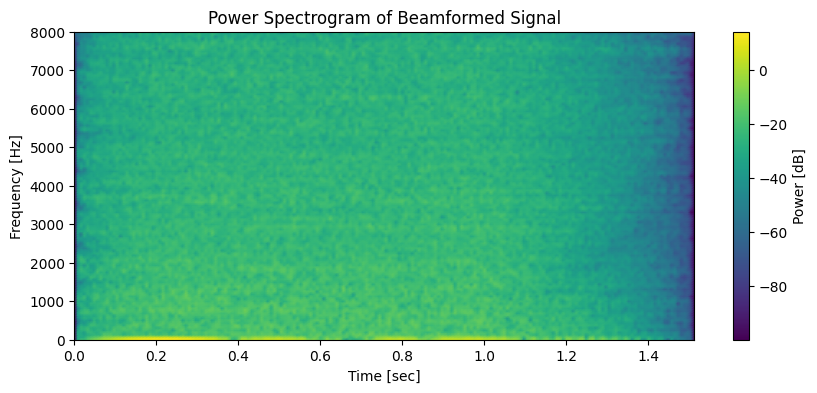

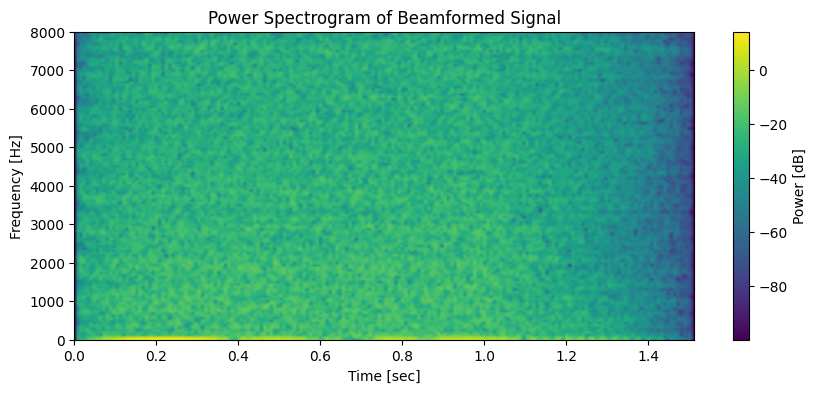

In [36]:
# 最終的に各スポットのスペクトログラムを表示

# 再構成パワースペクトログラムの表示
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft, 10 * np.log10(mean_spec + 1e-10), shading='gouraud')
plt.title('Power Spectrogram of Beamformed Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.ylim([0, room.fs / 2])  # サンプリング周波数の半分までを表示
plt.show()

# 再構成パワースペクトログラムの表示
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft, 10 * np.log10(beamform_spec[1] + 1e-10), shading='gouraud')
plt.title('Power Spectrogram of Beamformed Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.ylim([0, room.fs / 2])  # サンプリング周波数の半分までを表示
plt.show()

